In [49]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import keras_tuner
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten 
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, LeakyReLU

In [50]:
def build_model(input_lenght=4, depth=5, n_class=2):
    model = Sequential()
    
    # Primo strato (ha bisogno dell'input_shape implicito o esplicito)
    model.add(Dense(input_lenght, kernel_initializer='he_normal', input_shape=(input_lenght,)))
    model.add(BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.1)) # 'alpha' nelle vecchie versioni di Keras
    
    # I restanti strati nascosti (depth - 1)
    for _ in range(depth - 1):
        model.add(Dense(input_lenght, kernel_initializer='he_normal'))
        model.add(BatchNormalization())
        model.add(LeakyReLU(negative_slope=0.1))
        
    # Strato di Output (Sempre con Softmax per la classificazione!)
    model.add(Dense(n_class, activation='softmax', kernel_initializer='he_normal'))
    
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

In [97]:
def build_model2(input_lenght=4, depth=2, n_class=2):

    model = Sequential()

    model.add(Dense(
        4,
        input_shape=(input_lenght,),
        activation='relu'
    ))

    for _ in range(depth - 1):

        model.add(Dense(
            4,
            activation='relu'
        ))

    model.add(Dense(
        n_class,
        activation='softmax'
    ))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [74]:
iris = load_iris()

X = iris.data       
y = iris.target     

In [75]:
mask = y < 2

X_set_vers = X[mask]
y_set_vers = y[mask]

In [76]:
X_train_sv, X_test_sv, y_train_sv, y_test_sv = train_test_split(
    X_set_vers,
    y_set_vers,
    test_size=0.2,
    random_state=42
)

In [98]:
EPOCHS = 100
BATCH_SIZE = 32
Loss1 = []
Accuracy1 = []
for _ in range(1):
    model = build_model2(depth=4, n_class=2)
    fit = model.fit(X_train_sv, y_train_sv,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(X_test_sv, y_test_sv),
                    verbose=False,
                    shuffle=True)    
    loss1 = np.array(fit.history['loss'])
    accuracy1 = np.array(fit.history['accuracy'])
    Loss1.append(loss1)
    Accuracy1.append(accuracy1)

Loss1 = np.array(Loss1)         
Accuracy1 = np.array(Accuracy1) 

loss_mean1 = np.mean(Loss1, axis=0)
loss_std1 = np.std(Loss1, axis=0)

acc_mean1 = np.mean(Accuracy1, axis=0)
acc_std1 = np.std(Accuracy1, axis=0)

In [99]:
n_params = model.count_params()
print(n_params)

90


In [100]:

#QUESTO DA COPIARE AAAAAAAAAAAAAAA

import numpy as np
import tensorflow as tf

params = model.trainable_variables

# numero totale parametri
d = np.sum([tf.size(p).numpy() for p in params])

F = np.zeros((d, d))

N = len(X_train_sv)

for x, y in zip(X_train_sv, y_train_sv):

    x = tf.convert_to_tensor([x], dtype=tf.float32)
    y = tf.convert_to_tensor([y])

    with tf.GradientTape() as tape:

        preds = model(x, training=False)

        loss = tf.keras.losses.sparse_categorical_crossentropy(
            y,
            preds
        )

    grads = tape.gradient(loss, params)

    # flatten gradienti
    g = np.concatenate([
        tf.reshape(grad, [-1]).numpy()
        for grad in grads
    ])

    # outer product
    F += np.outer(g, g)

# media
F /= N

In [101]:
F

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.00052278, -0.00991589, ...,  0.        ,
        -0.00094251,  0.00094251],
       [ 0.        , -0.00991589,  0.29186984, ...,  0.        ,
         0.03313143, -0.03313142],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        , -0.00094251,  0.03313143, ...,  0.        ,
         0.06797692, -0.06797692],
       [ 0.        ,  0.00094251, -0.03313142, ...,  0.        ,
        -0.06797692,  0.06797691]], shape=(90, 90))

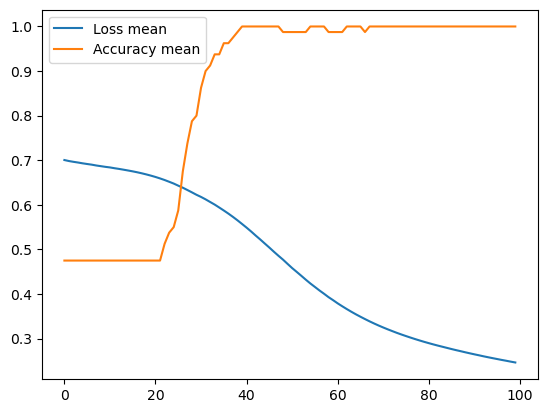

In [102]:

epochs = np.arange(EPOCHS)

plt.plot(epochs, loss_mean1, label="Loss mean")
plt.fill_between(
    epochs,
    loss_mean1 - loss_std1,
    loss_mean1 + loss_std1,
    alpha=0.3
)

plt.plot(epochs, acc_mean1, label="Accuracy mean")
plt.fill_between(
    epochs,
    acc_mean1 - acc_std1,
    acc_mean1 + acc_std1,
    alpha=0.3
)

plt.legend()
plt.show()

## Effective dimension

In [103]:
def effective_dimension(F, n):

    d = F.shape[0]

    kappa = n / (2 * np.pi * np.log(n))

    #normalization
    F_hat = d * F / np.trace(F)

    I = np.eye(d)

    M = I + kappa * F_hat

    sign, logdet = np.linalg.slogdet(M)

    d_eff = logdet / np.log(kappa)

    return d_eff

In [104]:
effective_dimension(F,5000)/F.shape[0]

np.float64(0.06955134772178329)

## Component analysis

In [66]:
t = F.trace()

eigvals, eigvecs = np.linalg.eigh(F)

for i in range(len(eigvals)):
    M = np.sort(eigvals)[::-1][i]
    M/t
    print(f'Information in eigenvalue {i}: {M/t:.2f}')

Information in eigenvalue 0: 0.38
Information in eigenvalue 1: 0.33
Information in eigenvalue 2: 0.16
Information in eigenvalue 3: 0.06
Information in eigenvalue 4: 0.05
Information in eigenvalue 5: 0.01
Information in eigenvalue 6: 0.00
Information in eigenvalue 7: 0.00
Information in eigenvalue 8: 0.00
Information in eigenvalue 9: 0.00
Information in eigenvalue 10: 0.00
Information in eigenvalue 11: 0.00
Information in eigenvalue 12: 0.00
Information in eigenvalue 13: 0.00
Information in eigenvalue 14: 0.00
Information in eigenvalue 15: 0.00
Information in eigenvalue 16: 0.00
Information in eigenvalue 17: 0.00
Information in eigenvalue 18: 0.00
Information in eigenvalue 19: 0.00
Information in eigenvalue 20: 0.00
Information in eigenvalue 21: 0.00
Information in eigenvalue 22: 0.00
Information in eigenvalue 23: 0.00
Information in eigenvalue 24: 0.00
Information in eigenvalue 25: 0.00
Information in eigenvalue 26: 0.00
Information in eigenvalue 27: 0.00
Information in eigenvalue 28: 

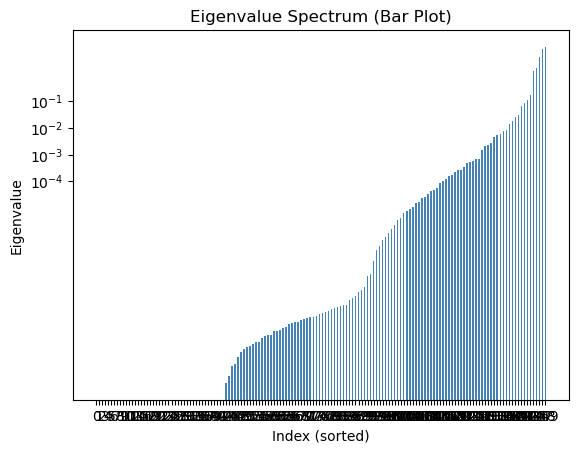

In [68]:
plt.bar(np.arange(len(eigvals)), eigvals, width=0.5, color='steelblue')

plt.xlabel("Index (sorted)")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalue Spectrum (Bar Plot)")
plt.yscale("log")
plt.xticks(np.arange(0, len(eigvals), 1))
plt.yticks([1e-4, 1e-3, 1e-2, 1e-1])
plt.show()

## PCA with Fisher matrix

Taking only the 2 combinations of parameters that contain the 96% of the information

In [13]:
U, S, VT = np.linalg.svd(F)

idx = np.argsort(eigvals)[::-1]

U = U[:, idx]

U2 = U[:, :2]

X_train_fisher2 = X_train_sv @ U2
X_test_fisher2 = X_test_sv @ U2

In [14]:
def build_model2(input_lenght=2, depth=5, n_class=2):
    model = Sequential()
    
    # Primo strato (ha bisogno dell'input_shape implicito o esplicito)
    model.add(Dense(input_lenght, kernel_initializer='he_normal', input_shape=(input_lenght,)))
    model.add(BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.1)) # 'alpha' nelle vecchie versioni di Keras
    
    # I restanti strati nascosti (depth - 1)
    for _ in range(depth - 1):
        model.add(Dense(input_lenght, kernel_initializer='he_normal'))
        model.add(BatchNormalization())
        model.add(LeakyReLU(negative_slope=0.1))
        
    # Strato di Output (Sempre con Softmax per la classificazione!)
    model.add(Dense(n_class, activation='softmax', kernel_initializer='he_normal'))
    
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

In [16]:
EPOCHS = 100
BATCH_SIZE = 32
Loss2 = []
Accuracy2 = []
for _ in range(40):
    model = build_model2(depth=5, n_class=2)
    fit = model.fit(X_train_fisher2, y_train_sv,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(X_test_fisher2, y_test_sv),
                    verbose=False,
                    shuffle=True)        
    loss = np.array(fit.history['loss'])
    accuracy  = np.array(fit.history['accuracy'])
    Loss2.append(loss)
    Accuracy2.append(accuracy)

In [17]:
Loss2 = np.array(Loss2)         
Accuracy2 = np.array(Accuracy2) 

loss_mean2 = np.mean(Loss2, axis=0)
loss_std2 = np.std(Loss2, axis=0)

acc_mean2 = np.mean(Accuracy2, axis=0)
acc_std2 = np.std(Accuracy2, axis=0)

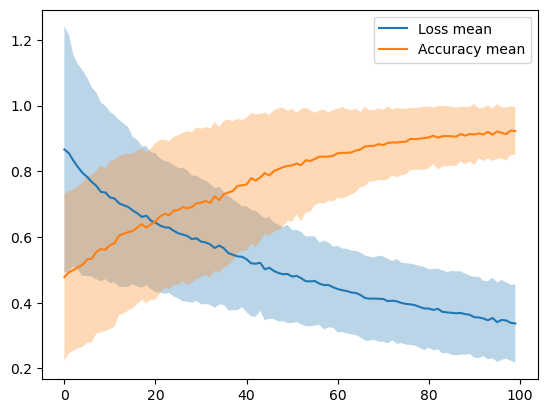

In [18]:
epochs = np.arange(EPOCHS)

plt.plot(epochs, loss_mean2, label="Loss mean")
plt.fill_between(
    epochs,
    loss_mean2 - loss_std2,
    loss_mean2 + loss_std2,
    alpha=0.3
)

plt.plot(epochs, acc_mean2, label="Accuracy mean")
plt.fill_between(
    epochs,
    acc_mean2 - acc_std2,
    acc_mean2 + acc_std2,
    alpha=0.3
)

plt.legend()
plt.show()

Half dimension of the parameter' space, similar results

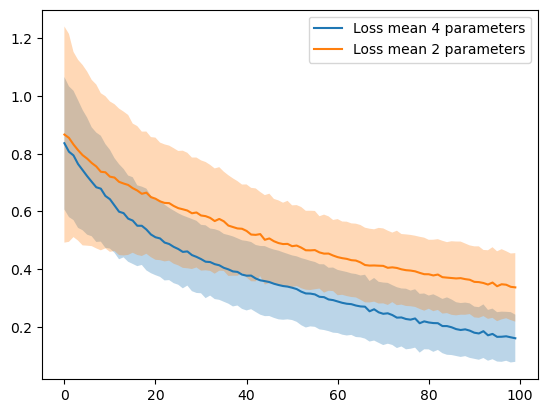

In [19]:
epochs = np.arange(EPOCHS)

plt.plot(epochs, loss_mean1, label="Loss mean 4 parameters")
plt.fill_between(
    epochs,
    loss_mean1 - loss_std1,
    loss_mean1 + loss_std1,
    alpha=0.3
)

plt.plot(epochs, loss_mean2, label="Loss mean 2 parameters")
plt.fill_between(
    epochs,
    loss_mean2 - loss_std2,
    loss_mean2 + loss_std2,
    alpha=0.3
)
plt.legend()
plt.show()

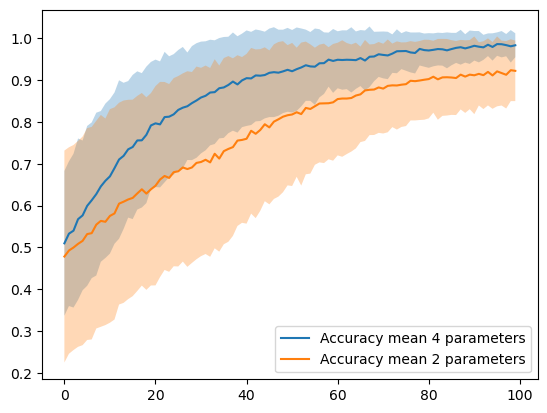

In [20]:
plt.plot(epochs, acc_mean1, label="Accuracy mean 4 parameters")
plt.fill_between(
    epochs,
    acc_mean1 - acc_std1,
    acc_mean1 + acc_std1,
    alpha=0.3
)
plt.plot(epochs, acc_mean2, label="Accuracy mean 2 parameters")
plt.fill_between(
    epochs,
    acc_mean2 - acc_std2,
    acc_mean2 + acc_std2,
    alpha=0.3
)

plt.legend()
plt.show()